# Notebook 06 — Full Comparison & Presentation Figures

Loads all results from notebooks 02–05 and produces 6 publication-quality figures.

| Figure | File | Description |
|--------|------|-------------|
| 1 | `fig1_ler_vs_noise_loglog.png` | Main result — all decoders, Stim log-log style, Wilson CIs |
| 2 | `fig2_suppression_bar.png` | Improvement over trivial at training noise |
| 3 | `fig3_training_curves.png` | All model training curves side by side |
| 4 | `fig4_confusion_heatmaps.png` | Confusion matrices MLP P1, MLP P2, LSTM |
| 5 | `fig5_failure_by_events.png` | Failure rate per #detection events |
| 6 | `fig6_detection_event_dist.png` | Detection event distribution + per-detector heatmap |

**Prerequisites:** Run notebooks 01 → 05 first.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from sklearn.metrics import confusion_matrix
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split
import os, warnings
warnings.filterwarnings('ignore')

os.makedirs("figures", exist_ok=True)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
SEED   = 42

# ── Global Stim/sinter plot style ─────────────────────────────────────────────
# Mirrors the exact look from the Stim getting-started notebook:
# ax.loglog() / ax.grid() / set_ylim(1e-5, 1)
# y-axis label: 'Logical Error Probability (per shot)'
# x-axis label: 'Physical Error Rate'
plt.rcParams.update({
    'font.family':        'DejaVu Sans',
    'font.size':          11,
    'axes.titlesize':     12,
    'axes.titleweight':   'bold',
    'axes.labelsize':     11,
    'axes.spines.top':    False,
    'axes.spines.right':  False,
    'axes.grid':          True,
    'grid.alpha':         0.35,
    'legend.framealpha':  0.9,
    'legend.fontsize':    9,
})

# Consistent colour palette — one colour per decoder, used in every figure
C = {
    'trivial': '#9E9E9E',
    'mlp_p1':  '#1E88E5',   # blue
    'mlp_p2':  '#E53935',   # red
    'lstm':    '#5C6BC0',   # indigo
    'mwpm':    '#2E7D32',   # green
    'train_p': '#FF8F00',   # amber
}

NOISE_LEVELS = [0.0005, 0.001, 0.002, 0.005, 0.01, 0.02]
SWEEP_SHOTS  = 50_000
ROUNDS, STABS = 9, 8

print("Style and constants configured.")

Style and constants configured.


---
## 1. Wilson CI Helper & Load All Results

In [2]:
def wilson_ci(num_errors, num_shots, z=1.96):
    p      = num_errors / num_shots
    denom  = 1 + z**2 / num_shots
    centre = (p + z**2 / (2*num_shots)) / denom
    margin = z * np.sqrt(p*(1-p)/num_shots + z**2/(4*num_shots**2)) / denom
    lo = np.clip(centre - margin, 1e-10, 1.0)
    hi = np.clip(centre + margin, 1e-10, 1.0)
    return float(p - lo), float(hi - p)


def make_yerr(ler_list, shots):
    pairs = [wilson_ci(max(1, round(l*shots)), shots) for l in ler_list]
    lo, hi = zip(*pairs)
    return np.array([lo, hi])


# ── Load base data ─────────────────────────────────────────────────────────────
det_all = np.load("data/detection_events.npy").astype(np.float32)
raw_all = np.load("data/raw_measurements.npy").astype(np.float32)
obs_all = np.load("data/observable_flips.npy").astype(np.float32).squeeze()

idx = np.arange(len(obs_all))
idx_tr, idx_tmp = train_test_split(idx, test_size=0.30,
                                    stratify=obs_all.astype(int), random_state=SEED)
idx_val, idx_te = train_test_split(idx_tmp, test_size=0.50,
                                    stratify=obs_all[idx_tmp].astype(int), random_state=SEED)

det_te = det_all[idx_te]; raw_te = raw_all[idx_te]; obs_te = obs_all[idx_te]
trivial = obs_te.mean()

# ── Model classes ─────────────────────────────────────────────────────────────
class SurfaceCodeDecoder(nn.Module):
    def __init__(self, input_dim, hidden=[256,128,64], dropout=0.3):
        super().__init__()
        layers, in_d = [], input_dim
        for i, h in enumerate(hidden):
            layers += [nn.Linear(in_d,h), nn.BatchNorm1d(h), nn.ReLU(),
                       nn.Dropout(dropout if i<len(hidden)-1 else 0.0)]
            in_d = h
        layers.append(nn.Linear(in_d, 1))
        self.net = nn.Sequential(*layers)
    def forward(self, x): return self.net(x).squeeze(-1)

class LSTMDecoder(nn.Module):
    def __init__(self, input_size=8, lstm_hidden=36, lstm_layers=2,
                 dense=[48,24,12], dropout=0.2):
        super().__init__()
        self.lstm = nn.LSTM(input_size, lstm_hidden, lstm_layers,
                            batch_first=True,
                            dropout=dropout if lstm_layers>1 else 0.0)
        layers, in_d = [], lstm_hidden
        for h in dense:
            layers += [nn.Linear(in_d,h), nn.ReLU(), nn.Dropout(dropout)]
            in_d = h
        layers.append(nn.Linear(in_d, 1))
        self.head = nn.Sequential(*layers)
    def forward(self, x):
        _, (h_n, _) = self.lstm(x)
        return self.head(h_n[-1]).squeeze(-1)

@torch.no_grad()
def predict(model, X, batch_size=1024):
    model.eval()
    ds = TensorDataset(torch.tensor(X))
    loader = DataLoader(ds, batch_size=batch_size)
    out = []
    for (Xb,) in loader:
        out.append((torch.sigmoid(model(Xb.to(DEVICE))) > 0.5).cpu().numpy())
    return np.concatenate(out)

# ── Load trained models ────────────────────────────────────────────────────────
def load_mlp(path):
    ck = torch.load(path, map_location='cpu', weights_only=False)
    m  = SurfaceCodeDecoder(ck['input_dim'], ck['hidden']).to(DEVICE)
    m.load_state_dict(ck['model_state'])
    return m, ck['test_ler']

def load_lstm(path):
    ck = torch.load(path, map_location='cpu', weights_only=False)
    m  = LSTMDecoder(ck['input_size'], ck['lstm_hidden'],
                     ck['lstm_layers'], ck['dense']).to(DEVICE)
    m.load_state_dict(ck['model_state'])
    return m, ck['test_ler']

mlp_p1, ler_mlp_p1 = load_mlp("models/decoder_part1.pt")
mlp_p2, ler_mlp_p2 = load_mlp("models/decoder_part2.pt")
lstm,   ler_lstm   = load_lstm("models/decoder_lstm.pt")

pred_p1   = predict(mlp_p1, det_te)
pred_p2   = predict(mlp_p2, raw_te)
pred_lstm = predict(lstm,   det_te.reshape(-1, ROUNDS, STABS))

# ── Load sweep results ────────────────────────────────────────────────────────
mwpm_data = np.load("results/mwpm_sweep.npy")
lstm_data = np.load("results/lstm_sweep.npy")
mwpm_lers = list(mwpm_data[:, 1])
lstm_lers = list(lstm_data[:, 1])

# MLP sweep — regenerate from saved models + sweep data
trivials, mlp1_lers, mlp2_lers = [], [], []
for p in NOISE_LEVELS:
    tag   = f"{int(p*10000):04d}"
    obs_s = np.load(f"data/sweep/obs_p{tag}.npy").astype(np.float32).squeeze()
    det_s = np.load(f"data/sweep/det_p{tag}.npy").astype(np.float32)
    raw_s = np.load(f"data/sweep/raw_p{tag}.npy").astype(np.float32)
    trivials.append(float(obs_s.mean()))
    mlp1_lers.append(float((predict(mlp_p1, det_s) != obs_s).mean()))
    mlp2_lers.append(float((predict(mlp_p2, raw_s) != obs_s).mean()))

print("All data loaded.")
print(f"  MLP P1 test LER : {100*ler_mlp_p1:.4f}%")
print(f"  MLP P2 test LER : {100*ler_mlp_p2:.4f}%")
print(f"  LSTM   test LER : {100*ler_lstm:.4f}%")
print(f"  MWPM   at p=0.001: {100*mwpm_lers[1]:.4f}%")
print(f"  Trivial LER      : {100*trivial:.4f}%")

All data loaded.
  MLP P1 test LER : 1.4467%
  MLP P2 test LER : 3.6600%
  LSTM   test LER : 1.0867%
  MWPM   at p=0.001: 0.2280%
  Trivial LER      : 5.4867%


---
## Figure 1 — Main Result: LER vs p (Stim Style, Log-Log)

This is the primary figure for the board presentation.
Exact Stim/sinter aesthetic: `ax.loglog()`, `ax.grid()`, `ax.set_ylim(1e-5, 1)`,
Wilson CI error bars, p² slope reference.

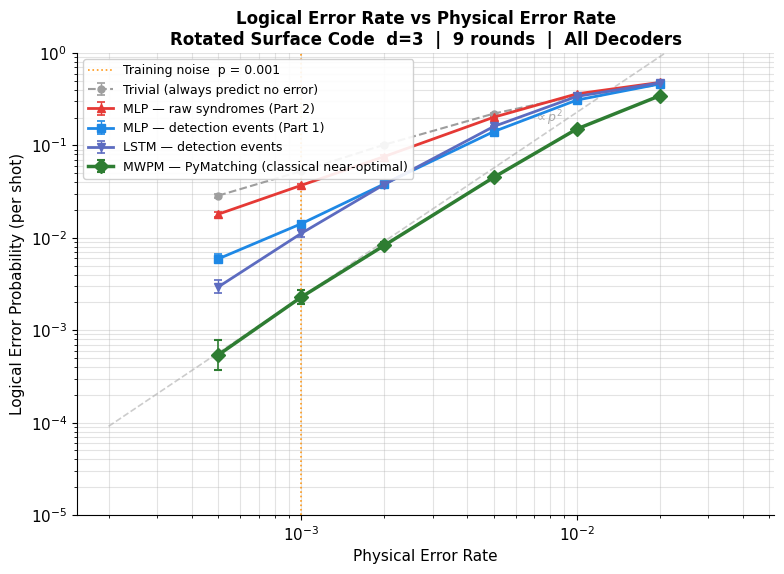

Saved → figures/fig1_ler_vs_noise_loglog.png


In [3]:
ps = np.array(NOISE_LEVELS)
S  = SWEEP_SHOTS

fig, ax = plt.subplots(1, 1, figsize=(9, 6))

# p² reference slope — anchor at MWPM p=0.001
p_ref = np.array([2e-4, 4e-2])
ax.plot(p_ref, mwpm_lers[1] * (p_ref/0.001)**2,
        ls='--', color='#CCCCCC', lw=1.2, zorder=0)
ax.text(7e-3, mwpm_lers[1]*(7e-3/0.001)**2*1.6,
        r'$\propto p^2$', color='#AAAAAA', fontsize=9, style='italic')

# Trivial
ax.errorbar(ps, trivials, yerr=make_yerr(trivials, S),
            fmt='o--', color=C['trivial'], lw=1.5, ms=5,
            capsize=3, capthick=1.2, elinewidth=1.0,
            label='Trivial (always predict no error)')

# MLP Part 2
ax.errorbar(ps, mlp2_lers, yerr=make_yerr(mlp2_lers, S),
            fmt='^-', color=C['mlp_p2'], lw=2, ms=6,
            capsize=3, capthick=1.2, elinewidth=1.0,
            label='MLP — raw syndromes (Part 2)')

# MLP Part 1
ax.errorbar(ps, mlp1_lers, yerr=make_yerr(mlp1_lers, S),
            fmt='s-', color=C['mlp_p1'], lw=2, ms=6,
            capsize=3, capthick=1.2, elinewidth=1.0,
            label='MLP — detection events (Part 1)')

# LSTM
ax.errorbar(ps, lstm_lers, yerr=make_yerr(lstm_lers, S),
            fmt='v-', color=C['lstm'], lw=2, ms=6,
            capsize=3, capthick=1.2, elinewidth=1.0,
            label='LSTM — detection events')

# MWPM
ax.errorbar(ps, mwpm_lers, yerr=make_yerr(mwpm_lers, S),
            fmt='D-', color=C['mwpm'], lw=2.5, ms=7,
            capsize=3, capthick=1.5, elinewidth=1.2,
            label='MWPM — PyMatching (classical near-optimal)')

# Training noise marker
ax.axvline(x=0.001, color=C['train_p'], lw=1.2, ls=':', alpha=0.9,
           label='Training noise  p = 0.001')

# ── Exact Stim/sinter style ─────────────────────────────────────────────────
ax.loglog()
ax.set_ylim(1e-5, 1)
ax.grid(which='both', alpha=0.35)
ax.set_ylabel('Logical Error Probability (per shot)')   # exact Stim label
ax.set_xlabel('Physical Error Rate')                    # exact Stim label
ax.set_title('Logical Error Rate vs Physical Error Rate\n'
             'Rotated Surface Code  d=3  |  9 rounds  |  All Decoders')
ax.legend(loc='upper left', framealpha=0.9)

fig.savefig('figures/fig1_ler_vs_noise_loglog.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved → figures/fig1_ler_vs_noise_loglog.png")

---
## Figure 2 — Suppression Bar Chart

Absolute LER and suppression factor at training noise p=0.001.

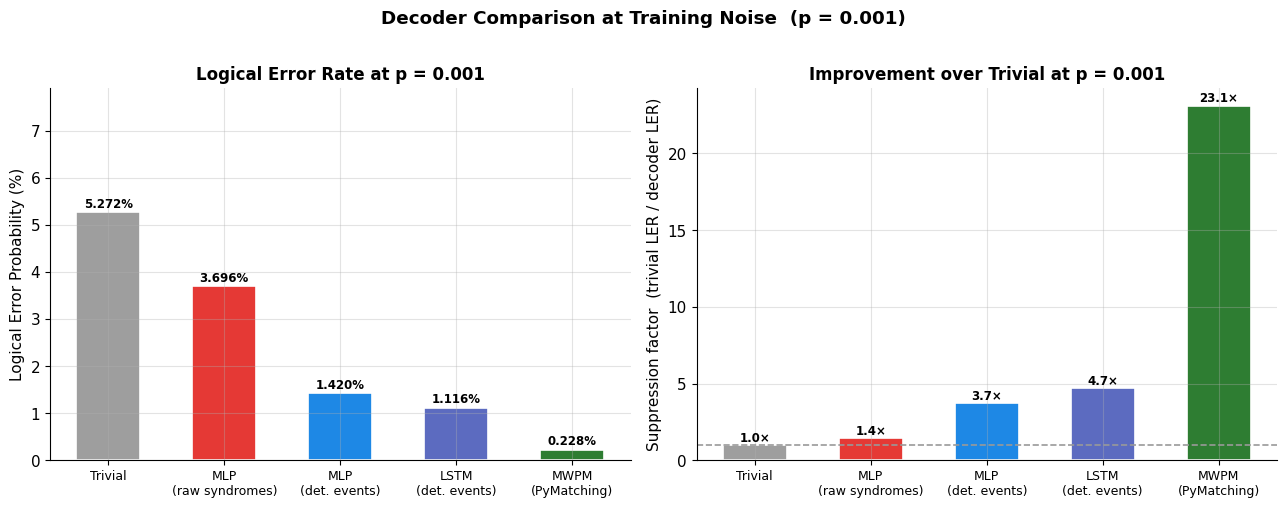

Saved → figures/fig2_suppression_bar.png


In [4]:
idx1     = NOISE_LEVELS.index(0.001)
t_ref    = trivials[idx1]
decoders = [
    ('Trivial',              t_ref,          C['trivial']),
    ('MLP\n(raw syndromes)', mlp2_lers[idx1],C['mlp_p2']),
    ('MLP\n(det. events)',   mlp1_lers[idx1],C['mlp_p1']),
    ('LSTM\n(det. events)',  lstm_lers[idx1],C['lstm']),
    ('MWPM\n(PyMatching)',   mwpm_lers[idx1],C['mwpm']),
]

names  = [d[0] for d in decoders]
lers   = [d[1] for d in decoders]
colors = [d[2] for d in decoders]
x_pos  = np.arange(len(decoders))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

# Left — absolute LER
bars = ax1.bar(x_pos, [l*100 for l in lers], color=colors,
               edgecolor='white', linewidth=1.2, width=0.55)
for bar, ler in zip(bars, lers):
    ax1.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.04,
             f'{100*ler:.3f}%', ha='center', va='bottom',
             fontsize=8.5, fontweight='bold')
ax1.set_xticks(x_pos); ax1.set_xticklabels(names, fontsize=9)
ax1.set_ylabel('Logical Error Probability (%)')
ax1.set_title('Logical Error Rate at p = 0.001')
ax1.set_ylim(0, t_ref * 100 * 1.5)

# Right — suppression over trivial
ratios = [t_ref/l if l > 0 else 0 for l in lers]
bars2  = ax2.bar(x_pos, ratios, color=colors,
                 edgecolor='white', linewidth=1.2, width=0.55)
for bar, r in zip(bars2, ratios):
    ax2.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.05,
             f'{r:.1f}×', ha='center', va='bottom',
             fontsize=8.5, fontweight='bold')
ax2.axhline(y=1.0, color='#999999', lw=1.2, ls='--')
ax2.set_xticks(x_pos); ax2.set_xticklabels(names, fontsize=9)
ax2.set_ylabel('Suppression factor  (trivial LER / decoder LER)')
ax2.set_title('Improvement over Trivial at p = 0.001')

plt.suptitle('Decoder Comparison at Training Noise  (p = 0.001)',
             fontweight='bold', y=1.01)
plt.tight_layout()
fig.savefig('figures/fig2_suppression_bar.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved → figures/fig2_suppression_bar.png")

---
## Figure 3 — Training Curves (All Models)

Loads training history saved by notebooks 02 and 05.

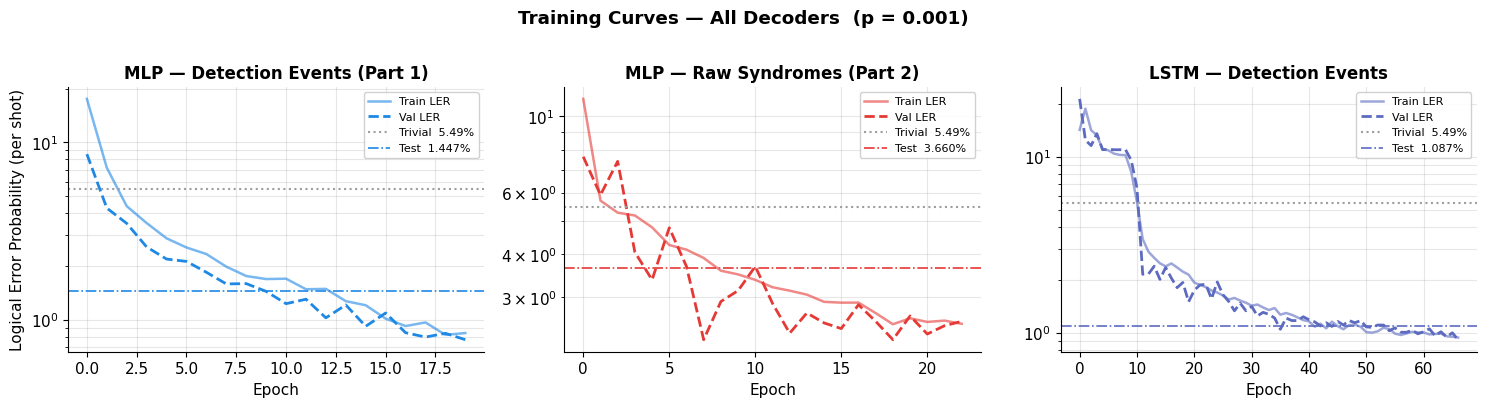

Saved → figures/fig3_training_curves.png


In [5]:
# Load saved training histories
ck_p1   = torch.load("models/decoder_part1.pt", map_location='cpu', weights_only=False)
ck_p2   = torch.load("models/decoder_part2.pt", map_location='cpu', weights_only=False)
ck_lstm = torch.load("models/decoder_lstm.pt",  map_location='cpu', weights_only=False)

hist_p1   = ck_p1.get('history',   {})
hist_p2   = ck_p2.get('history',   {})
hist_lstm = ck_lstm.get('history',  {})

fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=False)

configs = [
    (axes[0], hist_p1,   'MLP — Detection Events (Part 1)', C['mlp_p1'],  ler_mlp_p1),
    (axes[1], hist_p2,   'MLP — Raw Syndromes (Part 2)',    C['mlp_p2'],  ler_mlp_p2),
    (axes[2], hist_lstm, 'LSTM — Detection Events',         C['lstm'],    ler_lstm),
]

for ax, hist, title, color, test_ler in configs:
    if 'val_ler' not in hist:
        ax.text(0.5, 0.5, 'History not saved\n(re-run notebook 02 / 05)',
                transform=ax.transAxes, ha='center', va='center', color='grey')
        ax.set_title(title); continue

    ep = range(1, len(hist['val_ler'])+1)
    ax.semilogy([l*100 for l in hist.get('tr_ler', hist['val_ler'])],
                color=color, lw=1.8, alpha=0.6, label='Train LER')
    ax.semilogy([l*100 for l in hist['val_ler']],
                color=color, lw=2, ls='--', label='Val LER')
    ax.axhline(trivial*100, color=C['trivial'], lw=1.5, ls=':',
               label=f'Trivial  {100*trivial:.2f}%')
    ax.axhline(test_ler*100, color=color, lw=1.2, ls='-.',
               label=f'Test  {100*test_ler:.3f}%')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Logical Error Probability (per shot)' if ax is axes[0] else '')
    ax.set_title(title)
    ax.legend(fontsize=8)
    ax.grid(which='both', alpha=0.3)

plt.suptitle('Training Curves — All Decoders  (p = 0.001)',
             fontweight='bold', y=1.01)
plt.tight_layout()
fig.savefig('figures/fig3_training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved → figures/fig3_training_curves.png")

---
## Figure 4 — Confusion Matrix Heatmaps

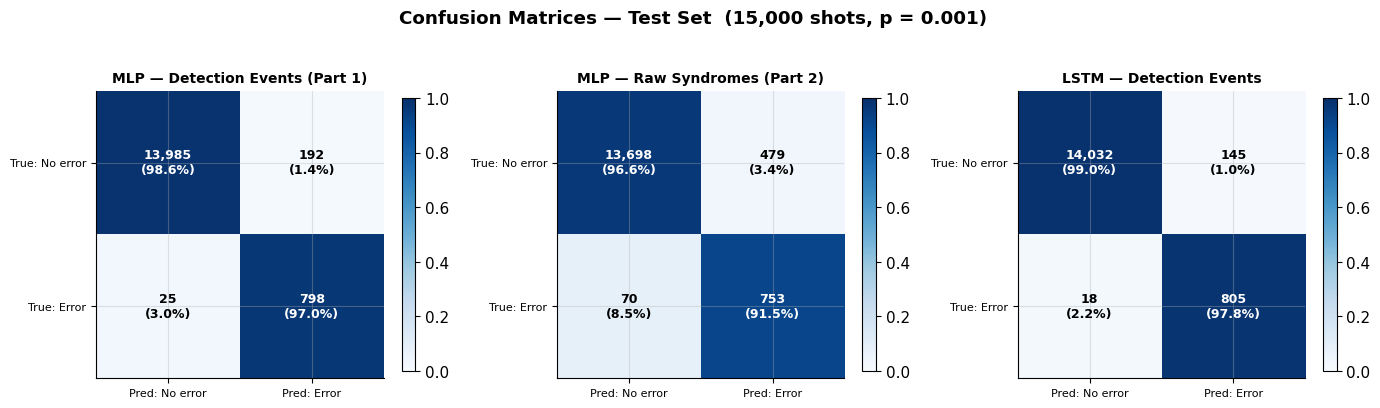

Saved → figures/fig4_confusion_heatmaps.png


In [6]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, preds, title, color in [
    (axes[0], pred_p1,   'MLP — Detection Events (Part 1)', C['mlp_p1']),
    (axes[1], pred_p2,   'MLP — Raw Syndromes (Part 2)',    C['mlp_p2']),
    (axes[2], pred_lstm, 'LSTM — Detection Events',         C['lstm']),
]:
    cm      = confusion_matrix(obs_te.astype(int), preds.astype(int))
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

    im = ax.imshow(cm_norm, cmap='Blues', vmin=0, vmax=1)
    ax.set_xticks([0,1])
    ax.set_yticks([0,1])
    ax.set_xticklabels(['Pred: No error', 'Pred: Error'], fontsize=8)
    ax.set_yticklabels(['True: No error', 'True: Error'], fontsize=8)
    ax.set_title(title, fontsize=10)

    for i in range(2):
        for j in range(2):
            tc = 'white' if cm_norm[i,j] > 0.55 else 'black'
            ax.text(j, i, f'{cm[i,j]:,}\n({100*cm_norm[i,j]:.1f}%)',
                    ha='center', va='center',
                    fontsize=9, fontweight='bold', color=tc)
    plt.colorbar(im, ax=ax, shrink=0.82)

plt.suptitle('Confusion Matrices — Test Set  (15,000 shots, p = 0.001)',
             fontweight='bold', y=1.02)
plt.tight_layout()
fig.savefig('figures/fig4_confusion_heatmaps.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved → figures/fig4_confusion_heatmaps.png")

---
## Figure 5 — Failure Rate vs #Detection Events

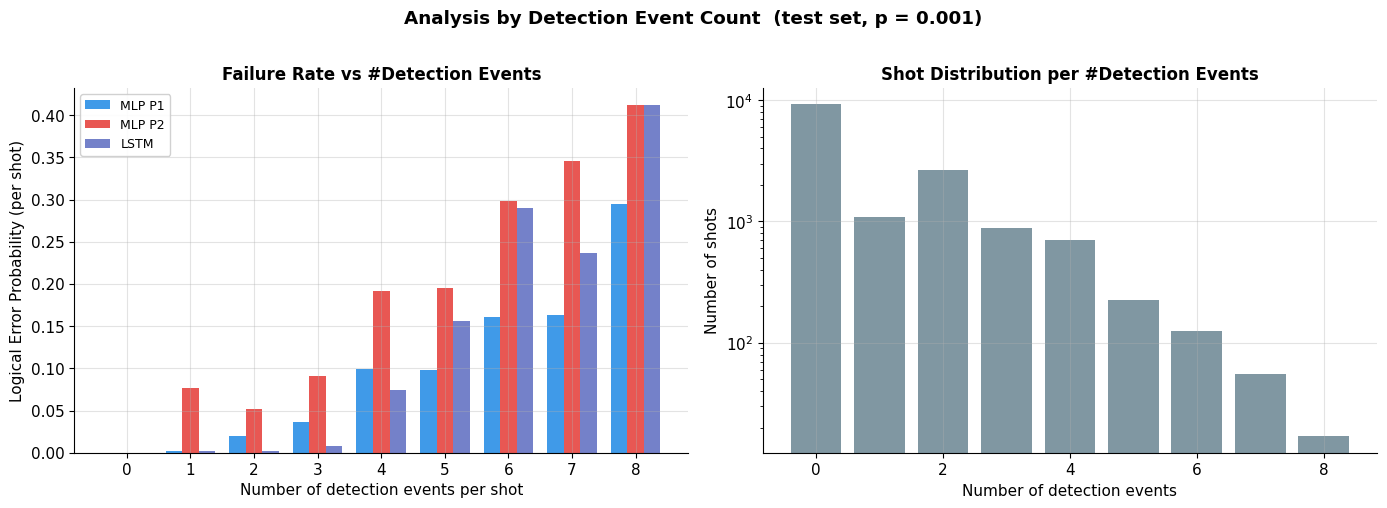

Saved → figures/fig5_failure_by_events.png


In [7]:
events_te = det_te.sum(axis=1).astype(int)

fail_p1   = (pred_p1   != obs_te)
fail_p2   = (pred_p2   != obs_te)
fail_lstm = (pred_lstm != obs_te)

ks, r1s, r2s, r3s, counts_k = [], [], [], [], []
for k in range(12):
    m = events_te == k
    if m.sum() < 10: continue
    ks.append(k)
    counts_k.append(m.sum())
    r1s.append(fail_p1[m].mean())
    r2s.append(fail_p2[m].mean())
    r3s.append(fail_lstm[m].mean())

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

x = np.arange(len(ks))
w = 0.26
ax1.bar(x-w, r1s, w, color=C['mlp_p1'], alpha=0.85, label='MLP P1')
ax1.bar(x,   r2s, w, color=C['mlp_p2'], alpha=0.85, label='MLP P2')
ax1.bar(x+w, r3s, w, color=C['lstm'],   alpha=0.85, label='LSTM')
ax1.set_xticks(x); ax1.set_xticklabels([str(k) for k in ks])
ax1.set_xlabel('Number of detection events per shot')
ax1.set_ylabel('Logical Error Probability (per shot)')  # Stim label
ax1.set_title('Failure Rate vs #Detection Events')
ax1.legend()

ax2.bar(ks, counts_k, color='#607D8B', alpha=0.8)
ax2.set_xlabel('Number of detection events')
ax2.set_ylabel('Number of shots')
ax2.set_title('Shot Distribution per #Detection Events')
ax2.set_yscale('log')

plt.suptitle('Analysis by Detection Event Count  (test set, p = 0.001)',
             fontweight='bold', y=1.01)
plt.tight_layout()
fig.savefig('figures/fig5_failure_by_events.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved → figures/fig5_failure_by_events.png")

---
## Figure 6 — Detection Event Distribution & Per-Detector Firing Rate

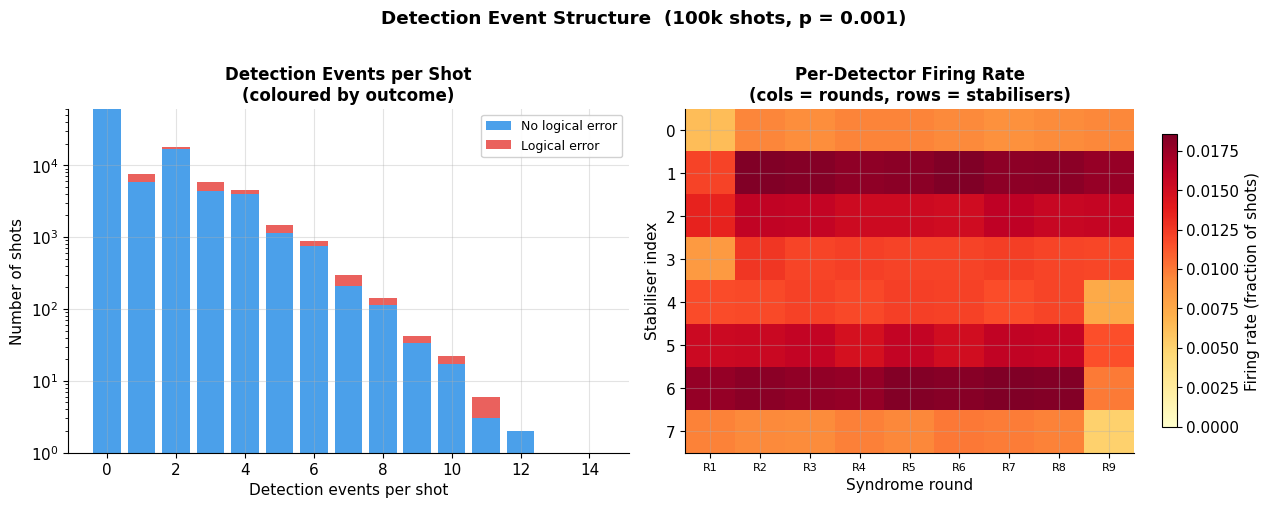

Saved → figures/fig6_detection_event_dist.png


In [8]:
events_all = det_all.sum(axis=1).astype(int)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left — stacked histogram by error outcome
ax = axes[0]
max_k = min(int(events_all.max()), 14)
no_err = [((events_all==k) & (obs_all==0)).sum() for k in range(max_k+1)]
err    = [((events_all==k) & (obs_all==1)).sum() for k in range(max_k+1)]
ks_plot = np.arange(max_k+1)
ax.bar(ks_plot, no_err, color=C['mlp_p1'], alpha=0.8, label='No logical error')
ax.bar(ks_plot, err, bottom=no_err, color=C['mlp_p2'], alpha=0.8, label='Logical error')
ax.set_xlabel('Detection events per shot')
ax.set_ylabel('Number of shots')
ax.set_title('Detection Events per Shot\n(coloured by outcome)')
ax.set_yscale('log')
ax.legend()

# Right — per-detector firing rate heatmap (Stim-style)
ax = axes[1]
rates = det_all.mean(axis=0).reshape(ROUNDS, STABS)
im = ax.imshow(rates.T, aspect='auto', cmap='YlOrRd', vmin=0)
ax.set_xlabel('Syndrome round')
ax.set_ylabel('Stabiliser index')
ax.set_title('Per-Detector Firing Rate\n(cols = rounds, rows = stabilisers)')
ax.set_xticks(range(ROUNDS))
ax.set_xticklabels([f'R{i+1}' for i in range(ROUNDS)], fontsize=8)
plt.colorbar(im, ax=ax, label='Firing rate (fraction of shots)', shrink=0.85)

plt.suptitle('Detection Event Structure  (100k shots, p = 0.001)',
             fontweight='bold', y=1.01)
plt.tight_layout()
fig.savefig('figures/fig6_detection_event_dist.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved → figures/fig6_detection_event_dist.png")

---
## Final Summary Table

In [9]:
idx1 = NOISE_LEVELS.index(0.001)

print("=" * 70)
print("FINAL RESULTS — d=3 Rotated Surface Code  |  p=0.001  |  15,000 test shots")
print("=" * 70)
print(f"  {'Decoder':<32}  {'LER':>9}  {'vs Trivial':>11}")
print("  " + "-"*55)

rows = [
    ("Trivial (always 0)",               trivial),
    ("MLP — raw syndromes  (Part 2)",     ler_mlp_p2),
    ("MLP — detection events (Part 1)",   ler_mlp_p1),
    ("LSTM — detection events",           ler_lstm),
    ("MWPM (PyMatching)",                 mwpm_lers[idx1]),
]
for name, ler in rows:
    ratio = f"{trivial/ler:.1f}×" if ler > 0 and name != 'Trivial (always 0)' else "—"
    print(f"  {name:<32}  {100*ler:>8.4f}%  {ratio:>11}")

print()
print("Figures saved to ./figures/")
for f in sorted(os.listdir("figures")):
    if f.endswith('.png'):
        print(f"  {f}")

FINAL RESULTS — d=3 Rotated Surface Code  |  p=0.001  |  15,000 test shots
  Decoder                                 LER   vs Trivial
  -------------------------------------------------------
  Trivial (always 0)                  5.4867%            —
  MLP — raw syndromes  (Part 2)       3.6600%         1.5×
  MLP — detection events (Part 1)     1.4467%         3.8×
  LSTM — detection events             1.0867%         5.0×
  MWPM (PyMatching)                   0.2280%        24.1×

Figures saved to ./figures/
  04_mwpm_vs_mlp.png
  05_lstm_training.png
  fig1_ler_vs_noise_loglog.png
  fig2_suppression_bar.png
  fig3_training_curves.png
  fig4_confusion_heatmaps.png
  fig5_failure_by_events.png
  fig6_detection_event_dist.png
